In [1]:
from importlib import reload

import tester
reload(tester)

<module 'tester' from '/home/ahutton/dev/uni/Part D Project/fc-tester/tester.py'>

In [2]:
test_runner = tester.Tester("/home/ahutton/dev/uni/Part D Project/fc-implementation")

In [3]:
test_runner.repo.list_branches()

['factor-trimming',
 'factor-trimming-no-collect',
 'factor-trimming-no-universe-check',
 'ft-nuc-ahash',
 'ft-nuc-fxhash',
 'ft-nuc-nohash',
 'ft-nuc-nohash-lcp',
 'ft-nuc-nohash-lcp-enum',
 'groundup',
 'groundup-lcp',
 'lcp',
 'lcp-factors',
 'main',
 'naive',
 'naive-no-collect',
 'naive-no-universe-check',
 'nc-nuc',
 'nc-nuc-nohash',
 'parallel']

In [4]:

from time import time
from datetime import datetime
from cases import formula_test_cases
from string import printable, ascii_letters
from cases.generation import random_word

ipsum = "Lorem ipsum dolor sit amet, consectetur adipiscing elit. Aliquam et magna non tellus interdum consectetur tristique id mauris. Ut tempor lacinia leo eu vulputate. Sed pellentesque porttitor tincidunt. Phasellus mattis nunc turpis, ut dapibus eros porta eu. Donec eget nibh elit. Nunc sed augue elit. Quisque pellentesque eget tortor vel blandit. Donec malesuada sapien vel nulla tempor venenatis. Aenean molestie, nibh nec consequat scelerisque, erat urna egestas enim, finibus tempus massa orci eu lectus. Vestibulum ac auctor enim. Pellentesque euismod, lorem eget condimentum auctor, turpis justo tincidunt diam, mattis eleifend sem orci sed ipsum. In nec metus maximus, dapibus diam id, dapibus mi. Morbi ac tristique arcu. Vestibulum non dictum lacus. Sed odio elit, vestibulum ut iaculis varius, placerat non sapien."
random = random_word(ascii_letters + "    ", 100)

sizes = [20, 40, 60, 80]
formula = 'z = x "ab" y && z = y "ab" x'
cases = [
    *formula_test_cases(formula, *[ipsum[:i] for i in sizes]),
    *formula_test_cases(formula, *[random[:i] for i in sizes]),
    *formula_test_cases(formula, *[printable[:i] for i in sizes])
]

case_labels = [
    *[f'{formula} on lorem ipsum len = {i}' for i in sizes],
    *[f'{formula} on random word len = {i}' for i in sizes],
    *[f'{formula} on worst case  len = {i}' for i in sizes]
]

bench_results = test_runner.benchmark_branches(
    cases=cases,
    branches=["groundup-lcp", "groundup"],
    num_trials=3
)
timestamp = datetime.fromtimestamp(time()).strftime("%Y-%m-%d %H-%M-%S")

0
*********************** Branch groundup-lcp ***********************
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor si']


Already on 'groundup-lcp'
 --> src/formula.rs:2:5
  |
2 | use crate::print_assignments;
  |     ^^^^^^^^^^^^^^^^^^^^^^^^
  |
  = note: `#[warn(unused_imports)]` (part of `#[warn(unused)]`) on by default

    Finished `release` profile [optimized + debuginfo] target(s) in 0.11s


Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor sit amet, consectetur ']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Ali']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Aliquam et magna non te']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'AYaxcNcX hAyG Bxzjgs']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'AYaxcNcX hAyG BxzjgsQRPWvpA EyeGkM Ffwzo']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'AYaxcNcX hAyG BxzjgsQRPWvpA EyeGkM Ff

Switched to branch 'groundup'
   Compiling fc-implementation v0.1.0 (/home/ahutton/dev/uni/Part D Project/fc-implementation)
 --> src/formula.rs:2:5
  |
2 | use crate::print_assignments;
  |     ^^^^^^^^^^^^^^^^^^^^^^^^
  |
  = note: `#[warn(unused_imports)]` (part of `#[warn(unused)]`) on by default

    Finished `release` profile [optimized + debuginfo] target(s) in 1.22s


Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor si']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor sit amet, consectetur ']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Ali']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Aliquam et magna non te']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'AYaxcNcX hAyG Bxzjgs']
Now Running ['./target/release/fc-implementation', '--quiet', '--pattern', 'z = x "ab" y && z = y "ab" x', '--text', 'AYaxcNcX hAyG BxzjgsQRPWvpA EyeGkM Ffwzo']
Now Running ['

In [5]:
import json

with open(f"./out/{timestamp}.json", "w") as f:
    json.dump(bench_results, f, indent=4)

In [6]:
# import json
# bench_results = json.load(open("./out/1-3 vars, 10-50 words 02-12-25.json"))

In [7]:

from perf import PerfEvent, plot_formula_comparison

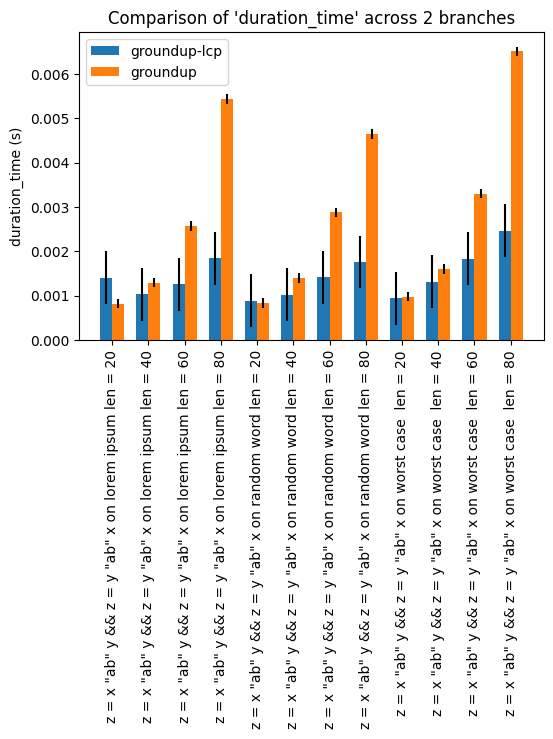

In [8]:
plot_formula_comparison(PerfEvent.DURATION_TIME, bench_results,  short_labels=True, case_labels=case_labels)